# Задача 4 — Вариант 17

**Датасет:** Students performance in exams (Kaggle)

**Цель (variant 17):** `reading score` — бинаризация: > mean → 0, <= mean → 1

**Модель 1:** `DecisionTreeClassifier`

**Модель 2:** `RandomForestClassifier` + GridSearch по `n_estimators` (грубый → уточнение с шагом 10)

In [25]:
!pip -q install kagglehub pandas scikit-learn matplotlib

In [26]:
import kagglehub
from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Загрузка данных через kagglehub
DATA_ROOT = Path(kagglehub.dataset_download('spscientist/students-performance-in-exams'))
csv_path = sorted(DATA_ROOT.rglob('*.csv'))[0]
data = pd.read_csv(csv_path)
data.head()

Using Colab cache for faster access to the 'students-performance-in-exams' dataset.


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [27]:
# Проверка данных на наличие пропущенных значений
print("Проверка пропущенных значений:\n", data.isna().sum())

# Цель по варианту 17: reading score
threshold = data['reading score'].mean()
y = (data['reading score'] <= threshold).astype(int)

# Признаки: удаляем целевой столбец из X
X = data.drop(columns=['reading score'])

# Преобразование категориальных признаков в числовые (как в примере)
cat_cols = [
    'gender',
    'race/ethnicity',
    'parental level of education',
    'lunch',
    'test preparation course',
]

for col in cat_cols:
    X[col] = pd.factorize(X[col])[0]

X.head()

Проверка пропущенных значений:
 gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,writing score
0,0,0,0,0,0,72,74
1,0,1,1,0,1,69,88
2,0,0,2,0,0,90,93
3,1,2,3,1,0,47,44
4,1,1,1,0,0,76,75


In [28]:
# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y,
)


Decision Tree Classifier


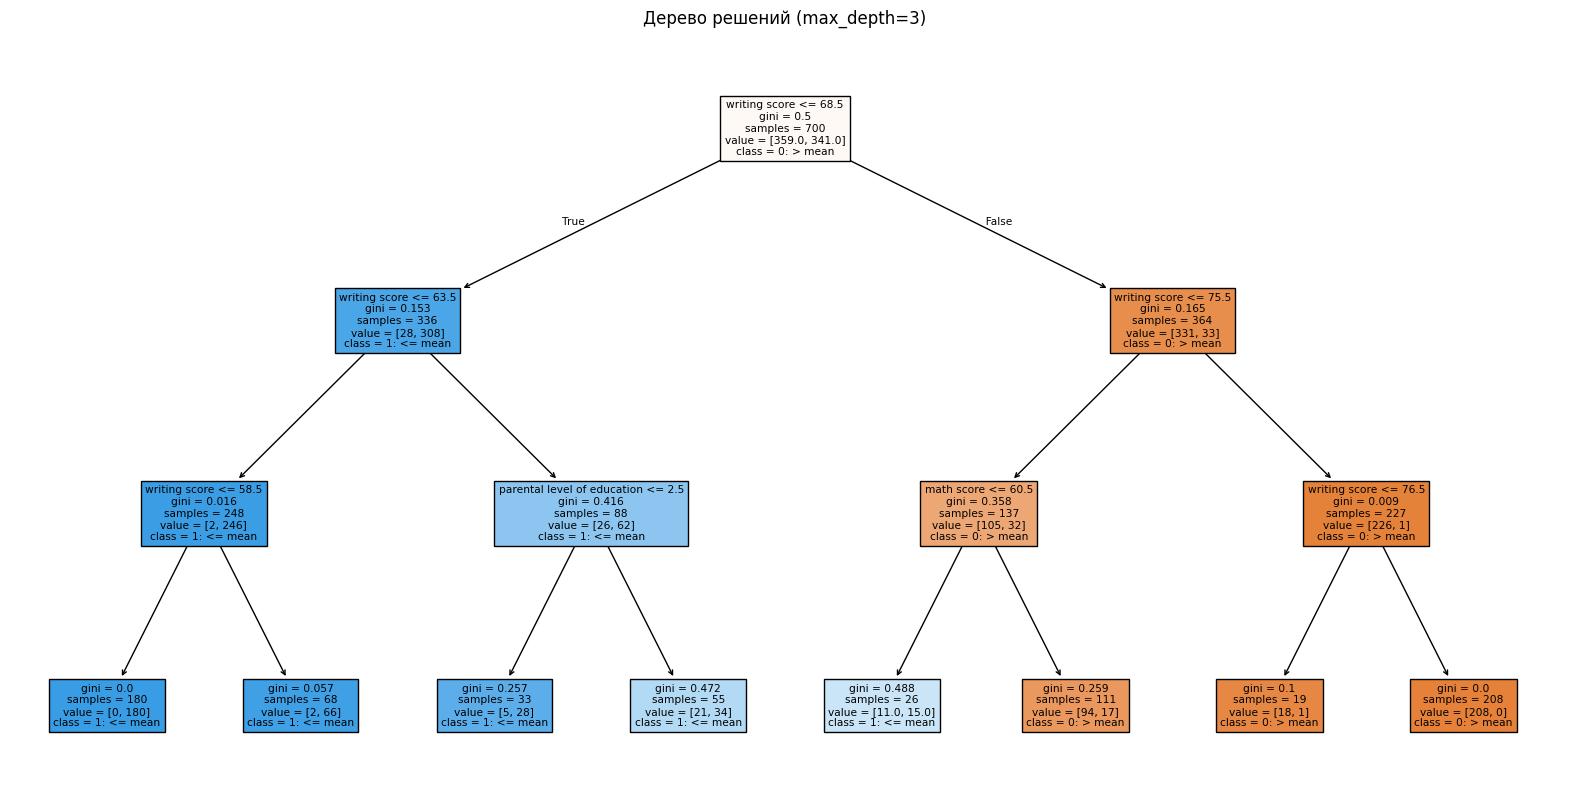


Правила классификации в виде неравенств:
|--- writing score <= 68.50
|   |--- writing score <= 63.50
|   |   |--- writing score <= 58.50
|   |   |   |--- class: 1
|   |   |--- writing score >  58.50
|   |   |   |--- class: 1
|   |--- writing score >  63.50
|   |   |--- parental level of education <= 2.50
|   |   |   |--- class: 1
|   |   |--- parental level of education >  2.50
|   |   |   |--- class: 1
|--- writing score >  68.50
|   |--- writing score <= 75.50
|   |   |--- math score <= 60.50
|   |   |   |--- class: 1
|   |   |--- math score >  60.50
|   |   |   |--- class: 0
|   |--- writing score >  75.50
|   |   |--- writing score <= 76.50
|   |   |   |--- class: 0
|   |   |--- writing score >  76.50
|   |   |   |--- class: 0


Оценка качества Decision Tree:
Precision: 0.8509316770186336
Recall: 0.9383561643835616
F1-score: 0.8925081433224755


In [29]:
# 1) Decision Tree Classifier + визуализация + правила
print("\nDecision Tree Classifier")

dtc = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=3)
dtc.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(
    dtc,
    filled=True,
    feature_names=X.columns,
    class_names=['0: > mean', '1: <= mean'],
)
plt.title("Дерево решений (max_depth=3)")
plt.show()

tree_rules = export_text(dtc, feature_names=list(X.columns))
print("\nПравила классификации в виде неравенств:")
print(tree_rules)

# Оценка качества
y_pred_dtc = dtc.predict(X_test)
print("\nОценка качества Decision Tree:")
print("Precision:", precision_score(y_test, y_pred_dtc))
print("Recall:", recall_score(y_test, y_pred_dtc))
print("F1-score:", f1_score(y_test, y_pred_dtc))

In [30]:
# 2) Random Forest Classifier — 1 этап (крупные шаги по n_estimators)
print("\nRandom Forest Classifier")

param_grid_rough = {
    'n_estimators': [50, 100, 200, 300, 400, 500],
}

grid_search_rough = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    param_grid=param_grid_rough,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=0,
)

grid_search_rough.fit(X_train, y_train)
print("\nЛучшие параметры после первого поиска:", grid_search_rough.best_params_)


Random Forest Classifier

Лучшие параметры после первого поиска: {'n_estimators': 100}


In [31]:
# 2) Random Forest Classifier — 2 этап (уточнение n_estimators с шагом 10)
best_n_estimators = grid_search_rough.best_params_['n_estimators']

start = max(10, best_n_estimators - 50)
stop = best_n_estimators + 50

param_grid_fine = {
    'n_estimators': list(range(start, stop, 10)),
}

grid_search_fine = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    param_grid=param_grid_fine,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=0,
)

grid_search_fine.fit(X_train, y_train)
print("\nЛучшие параметры после точного поиска:", grid_search_fine.best_params_)


Лучшие параметры после точного поиска: {'n_estimators': 100}



Оценка качества оптимизированного Random Forest:
Precision: 0.8851351351351351
Recall: 0.8972602739726028
F1-score: 0.891156462585034

Сравнение моделей по F1-score:
Decision Tree: 0.8925081433224755
Random Forest: 0.891156462585034

Важность признаков:
                       Feature  Importance
6                writing score    0.570282
5                   math score    0.266853
2  parental level of education    0.052018
1               race/ethnicity    0.037291
0                       gender    0.030117
4      test preparation course    0.023732
3                        lunch    0.019707


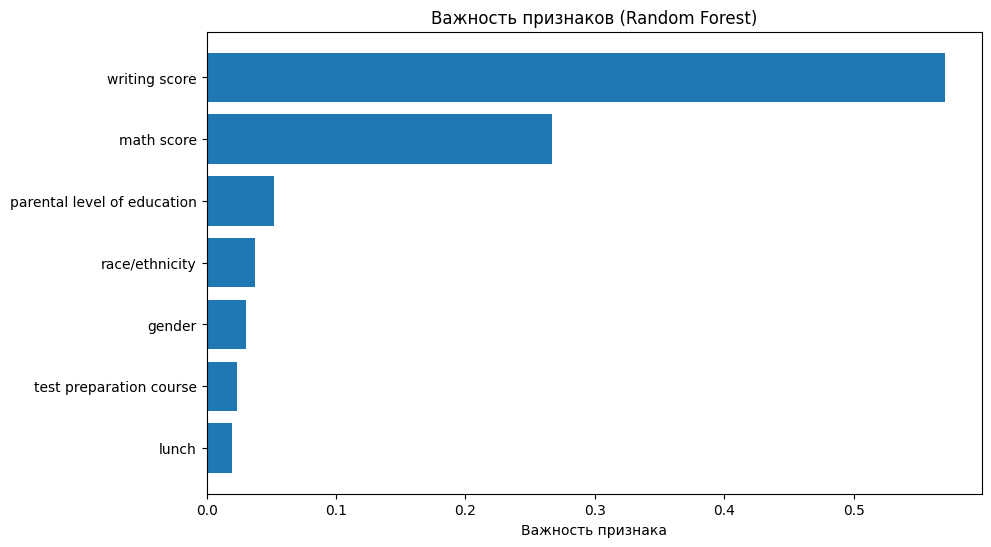

In [32]:
# Оценка лучшей модели Random Forest
best_rfc = grid_search_fine.best_estimator_
y_pred_best_rfc = best_rfc.predict(X_test)

print("\nОценка качества оптимизированного Random Forest:")
print("Precision:", precision_score(y_test, y_pred_best_rfc))
print("Recall:", recall_score(y_test, y_pred_best_rfc))
print("F1-score:", f1_score(y_test, y_pred_best_rfc))

# Сравнение моделей
print("\nСравнение моделей по F1-score:")
print("Decision Tree:", f1_score(y_test, y_pred_dtc))
print("Random Forest:", f1_score(y_test, y_pred_best_rfc))

# Анализ важности признаков
feature_importances = best_rfc.feature_importances_
features_df = pd.DataFrame(
    {
        'Feature': X.columns,
        'Importance': feature_importances,
    }
).sort_values('Importance', ascending=False)

print("\nВажность признаков:")
print(features_df)

# Визуализация важности признаков
plt.figure(figsize=(10, 6))
plt.barh(features_df['Feature'], features_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Важность признака')
plt.title('Важность признаков (Random Forest)')
plt.show()

## Итог

- Сформирована целевая переменная по `reading score` (порог = среднее).
- Обучено дерево решений (`DecisionTreeClassifier`, `max_depth=3`), выведены правила и визуализация.
- Обучён случайный лес (`RandomForestClassifier`), выполнен GridSearch по `n_estimators` в 2 этапа.
- Посчитаны precision/recall/F1 на тестовой выборке и выполнено сравнение моделей по F1-score.